In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency
from scipy import stats

In [2]:
csv_file = 'C:/Users/artal/Desktop/OpenClassrooms/Projet 9/customers.csv'
customers = pd.read_csv(csv_file,delimiter=";")
csv_file = 'C:/Users/artal/Desktop/OpenClassrooms/Projet 9/products.csv'
products = pd.read_csv(csv_file,delimiter=";")
csv_file = 'C:/Users/artal/Desktop/OpenClassrooms/Projet 9/Transactions.csv'
transactions = pd.read_csv(csv_file,delimiter=";")

C:\Users\artal\AppData\Local\Temp\ipykernel_18464\3654770553.py:6: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(csv_file,delimiter=";")


In [3]:
customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [4]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [5]:
transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


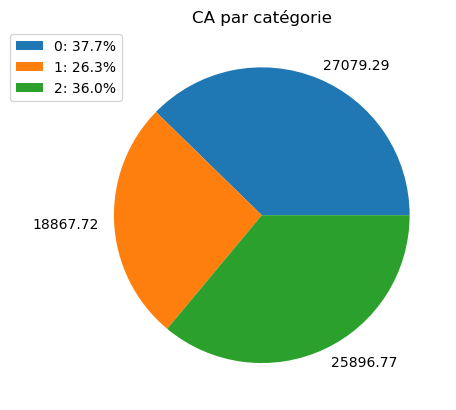

In [6]:
total_categ = products.groupby('categ')['price'].sum()
total = total_categ.sum()
labels_legende = [f"{cat}: {val / total * 100:.1f}%" for cat, val in zip(total_categ.index, total_categ.values)]
plt.pie(total_categ,labels = total_categ)
plt.title('CA par catégorie')
plt.legend(labels=labels_legende,loc="center left", bbox_to_anchor=(-0.2, 0.9))

In [7]:
total_categ

categ
0    27079.29
1    18867.72
2    25896.77
Name: price, dtype: float64

In [8]:
total = pd.merge(transactions,products,on='id_prod',how='inner')
total = pd.merge(total,customers,on='client_id',how='inner')
total['date'] = pd.to_datetime(total['date'])
total['date'] = total['date'].dt.strftime('%Y/%m')
total.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1259,2021/03,s_1,c_329,11.99,0,f,1967
1,0_1390,2021/03,s_2,c_664,19.37,0,m,1960
2,0_1352,2021/03,s_3,c_580,4.50,0,m,1988
3,0_1458,2021/03,s_4,c_7912,6.55,0,f,1989
4,0_1358,2021/03,s_5,c_2033,16.49,0,f,1956


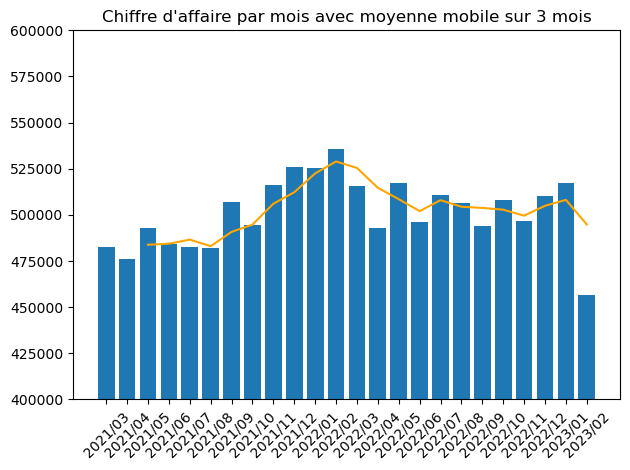

In [9]:
total_date = total.groupby('date')['price'].sum().reset_index()
total_date['moyenne'] = total_date['price'].rolling(window=3).mean()
plt.bar(total_date['date'],total_date['price'])
plt.plot(total_date['date'], total_date['moyenne'], color='orange', linestyle='-', label='Moyenne Mobile 3 Mois')
plt.xticks(rotation=45)
plt.title('Chiffre d\'affaire par mois avec moyenne mobile sur 3 mois')
plt.ylim(400000,600000)
plt.tight_layout()

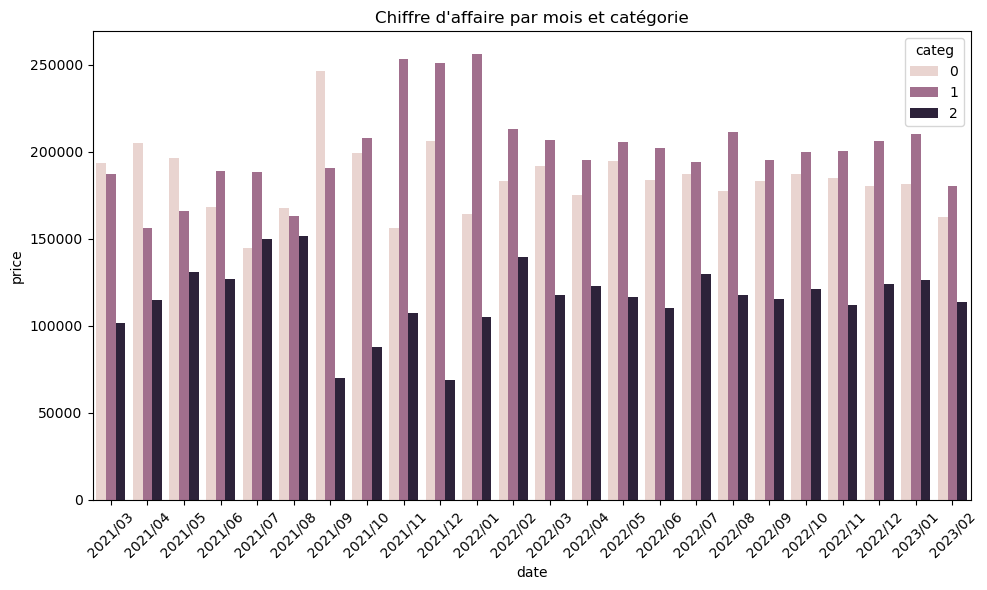

In [10]:
total_date = total.groupby(['date','categ'])['price'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=total_date,x='date',y='price',hue='categ')
plt.title('Chiffre d\'affaire par mois et catégorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

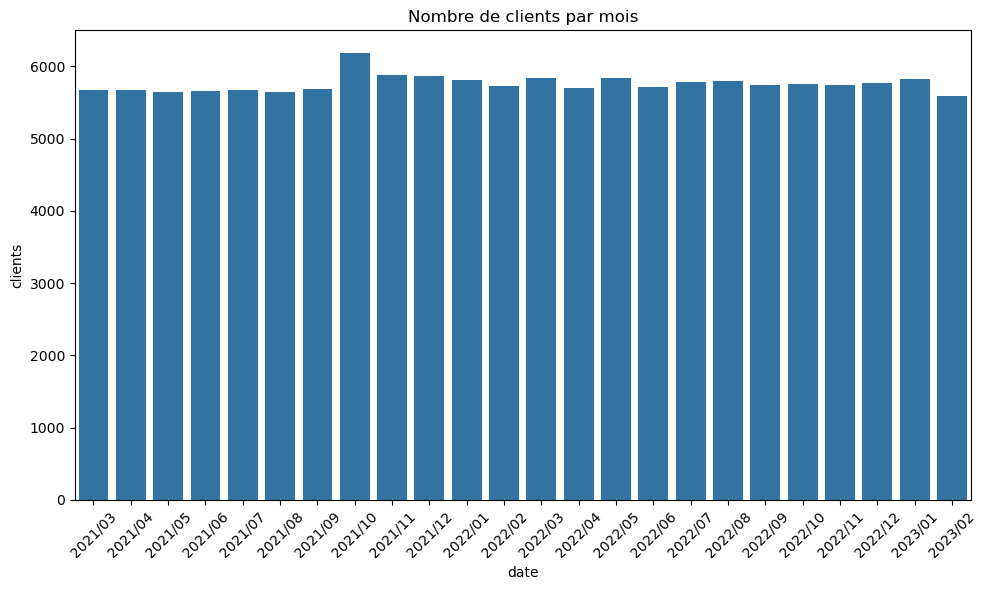

In [11]:
total_client = total.groupby('date')['client_id'].nunique().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=total_client,x='date',y='client_id')
plt.ylabel('clients')
plt.title('Nombre de clients par mois')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

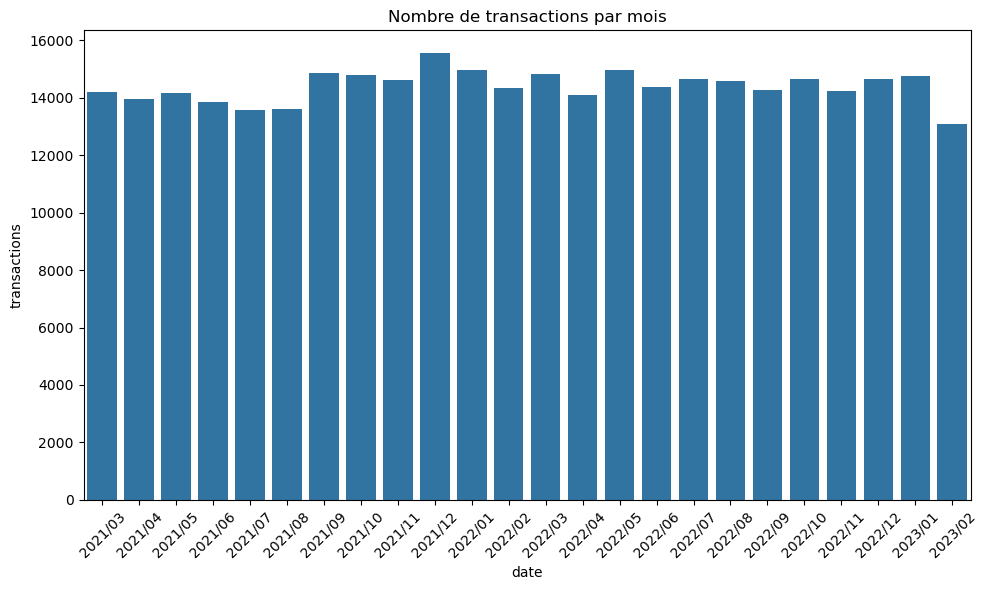

In [12]:
total_transactions = total.groupby('date')['session_id'].nunique().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=total_transactions,x='date',y='session_id')
plt.ylabel('transactions')
plt.title('Nombre de transactions par mois')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

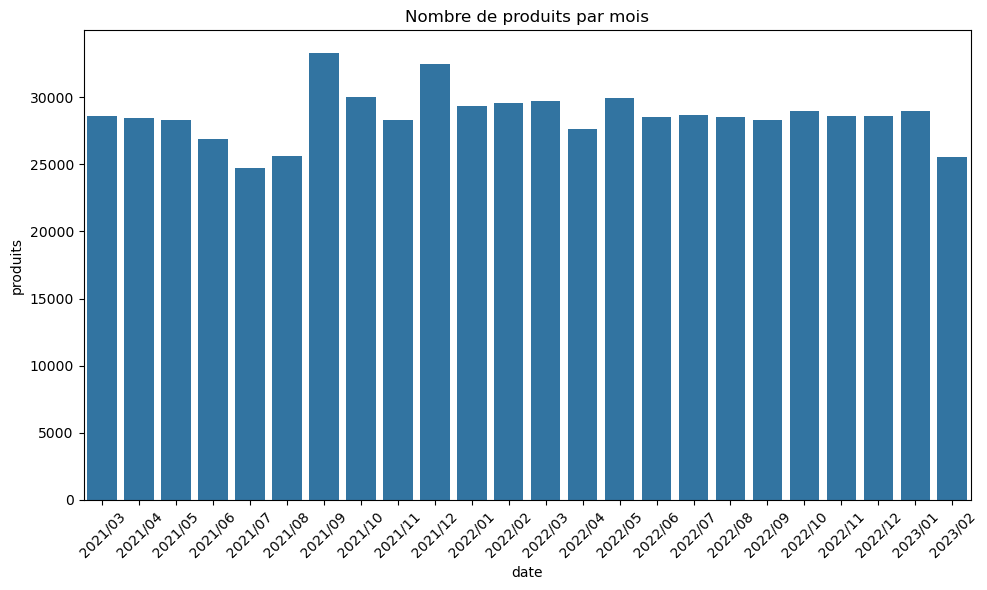

In [13]:
total_produits = total.groupby('date')['id_prod'].count().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=total_produits,x='date',y='id_prod')
plt.ylabel('produits')
plt.title('Nombre de produits par mois')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
flop_top = total.groupby(['categ','id_prod'])['date'].count().reset_index().rename(columns={'date':'nombre'}).sort_values(by='nombre',ascending=False)
flop_top

,categ,id_prod,nombre
2591,1,1_369,2340
2644,1,1_417,2269
2641,1,1_414,2246
2733,1,1_498,2202
2653,1,1_425,2163
...,...,...,...
1792,0,0_549,1
2166,0,0_886,1
549,0,0_1498,1
1784,0,0_541,1


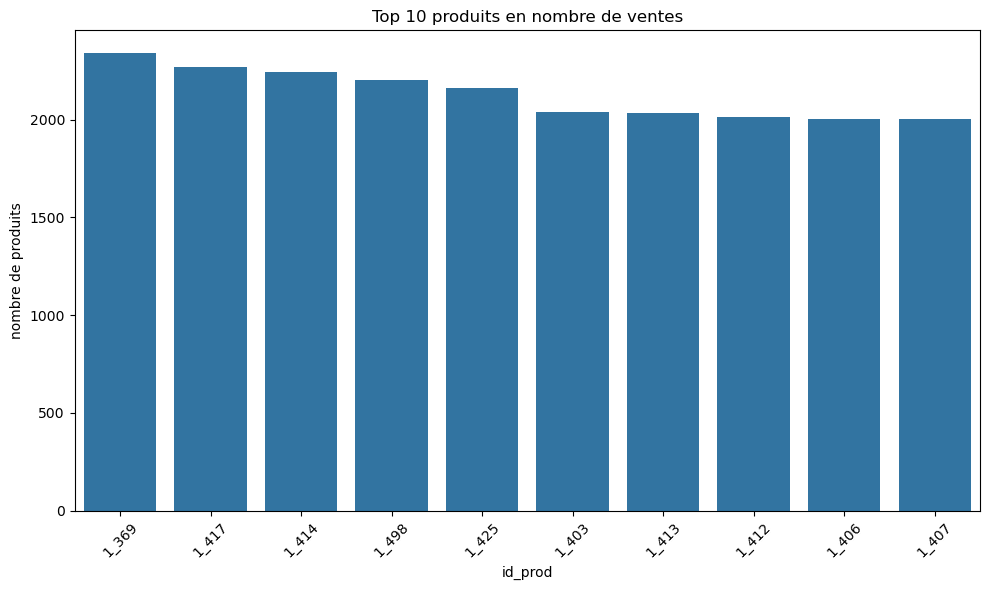

In [15]:
top_10 = flop_top.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_10,x='id_prod',y='nombre')
plt.ylabel('nombre de produits')
plt.title('Top 10 produits en nombre de ventes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

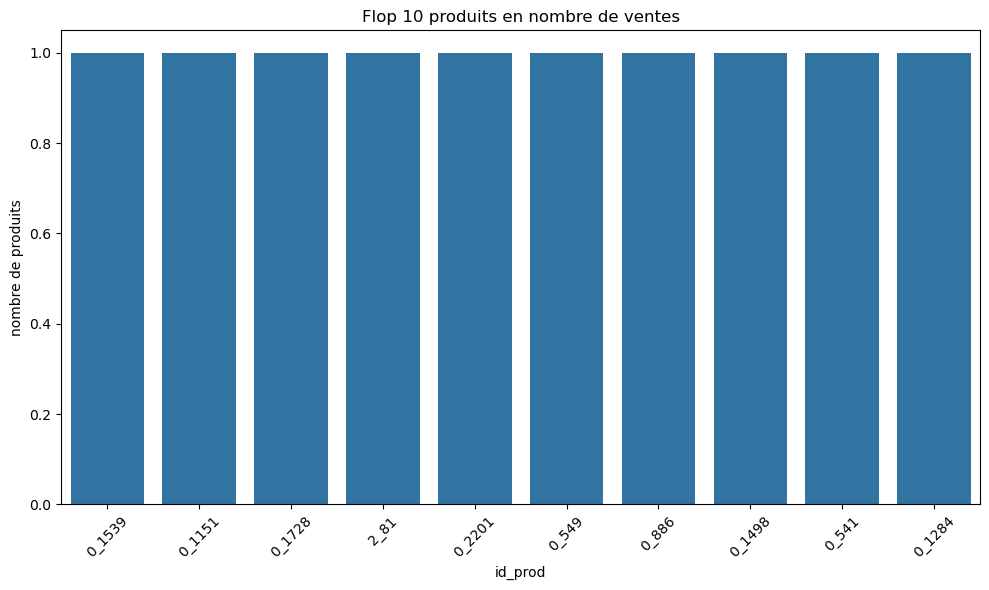

In [16]:
flop_10 = flop_top.tail(10)
plt.figure(figsize=(10,6))
sns.barplot(data=flop_10,x='id_prod',y='nombre')
plt.ylabel('nombre de produits')
plt.title('Flop 10 produits en nombre de ventes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
flop_top_ca = total.groupby('id_prod')['price'].sum().reset_index().sort_values(by='price',ascending=False)
flop_top_ca


,id_prod,price
3096,2_159,94893.50
3070,2_135,69334.95
3045,2_112,65407.76
3034,2_102,60736.78
3152,2_209,56971.86
...,...,...
665,0_1601,1.99
1784,0_541,1.99
719,0_1653,1.98
313,0_1284,1.38


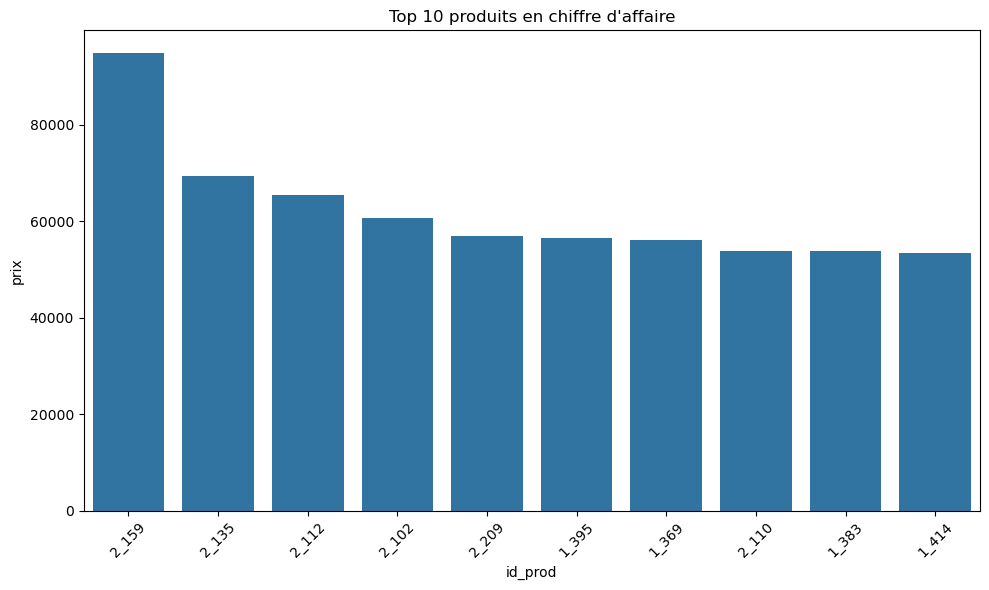

In [18]:
top_10_ca = flop_top_ca.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_10_ca,x='id_prod',y='price')
plt.ylabel('prix')
plt.title('Top 10 produits en chiffre d\'affaire')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

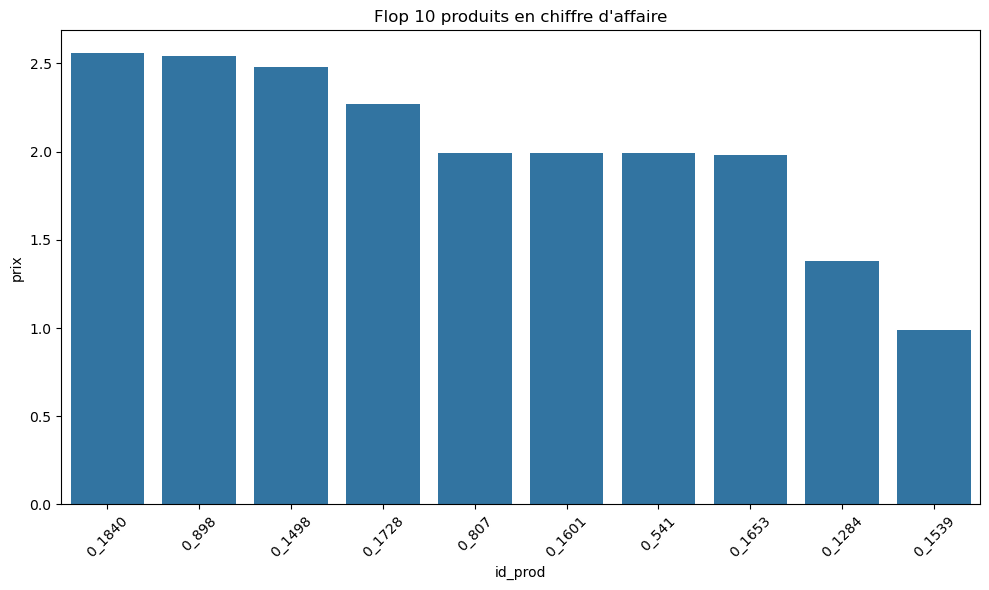

In [19]:
flop_10_ca = flop_top_ca.tail(10)
plt.figure(figsize=(10,6))
sns.barplot(data=flop_10_ca,x='id_prod',y='price')
plt.ylabel('prix')
plt.title('Flop 10 produits en chiffre d\'affaire')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
categ_nb = total.groupby('categ')['date'].count().reset_index().rename(columns={'date':'nombre'}).sort_values(by='nombre',ascending=False)
categ_nb


,categ,nombre
0,0,415459
1,1,235592
2,2,36483


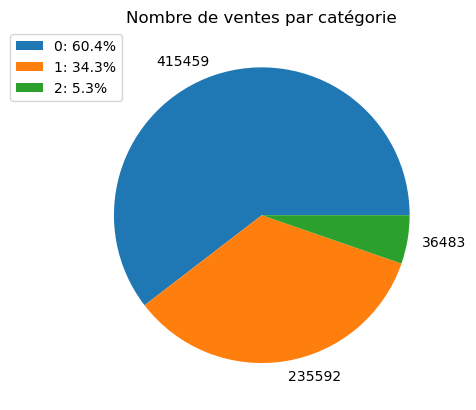

In [21]:
total_nb = categ_nb['nombre'].sum()
labels_legende = categ_nb.apply(lambda row: f"{row['categ']}: {row['nombre'] / total_nb * 100:.1f}%", axis=1)
plt.pie(categ_nb['nombre'],labels=categ_nb['nombre'])
plt.title('Nombre de ventes par catégorie')
plt.legend(labels=labels_legende,loc="center left", bbox_to_anchor=(-0.2, 0.9))

In [22]:
b2b = total.groupby('client_id')['price'].sum().reset_index().sort_values(by='price',ascending=False)
liste_b2b = b2b['client_id'].head(4)
liste_b2b

677     c_1609
4388    c_4958
6337    c_6714
2724    c_3454
Name: client_id, dtype: object

In [23]:
total_b2b = total[total['client_id'].isin(liste_b2b)]
total_b2b.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth
6,0_1304,2021/03,s_7,c_1609,5.86,0,m,1980
13,0_1159,2021/03,s_7,c_1609,7.99,0,m,1980
50,0_1431,2021/03,s_33,c_3454,10.99,0,m,1969
78,0_1425,2021/03,s_46,c_1609,12.99,0,m,1980
88,0_1469,2021/03,s_53,c_1609,14.99,0,m,1980


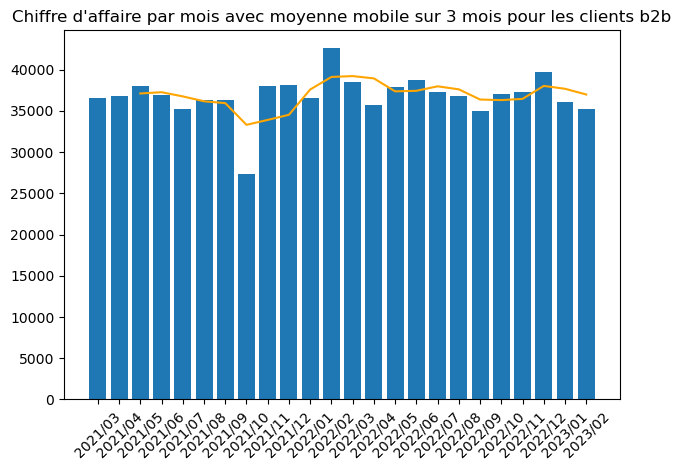

In [24]:
total_b2b = total_b2b.groupby('date')['price'].sum().reset_index()
total_b2b['moyenne'] = total_b2b['price'].rolling(window=3).mean()
plt.bar(total_b2b['date'],total_b2b['price'])
plt.plot(total_b2b['date'], total_b2b['moyenne'], color='orange', linestyle='-', label='Moyenne Mobile 3 Mois')
plt.xticks(rotation=45)
plt.title('Chiffre d\'affaire par mois avec moyenne mobile sur 3 mois pour les clients b2b')
plt.tight_layout()

In [25]:
client_ca = total.groupby('client_id')['price'].sum().reset_index().sort_values(by='price')
client_ca.head()

,client_id,price
8151,c_8351,6.31
7918,c_8140,8.30
7889,c_8114,9.98
4044,c_4648,11.20
3855,c_4478,13.36


In [26]:
cumul_ca = np.cumsum(client_ca['price']) / client_ca['price'].sum()
n = len(cumul_ca)
cumul_pop = np.arange(1,n+1)/n
cumul_ca = np.insert(cumul_ca,0,0)
cumul_pop = np.insert(cumul_pop,0,0)

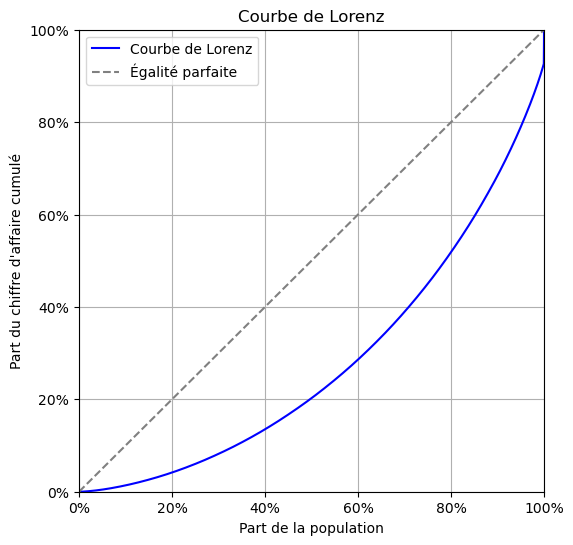

In [27]:
plt.figure(figsize=(6, 6))
plt.plot(cumul_pop, cumul_ca, label='Courbe de Lorenz', color='blue')
plt.plot([0, 1], [0, 1], '--', label='Égalité parfaite', color='gray')
plt.xlabel("Part de la population")
plt.ylabel("Part du chiffre d'affaire cumulé")
plt.title("Courbe de Lorenz")
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(True)
plt.show()

In [28]:
def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array) / (n * np.sum(array))) - (n + 1) / n
print(gini(client_ca['price'].values))

0.44189587995615653


In [29]:
total = total[~total['client_id'].isin(liste_b2b)]


In [30]:
total['age']=2025-total['birth']

In [31]:
stats.pearsonr(total['age'],total['price'])

PearsonRResult(statistic=-0.19578627516158276, pvalue=0.0)

In [32]:
montant_total = total.groupby(['client_id', 'age'])['price'].sum().reset_index()
montant_total

,client_id,age,price
0,c_1,70,629.02
1,c_10,69,1353.60
2,c_100,33,254.85
3,c_1000,59,2291.88
4,c_1001,43,1823.85
...,...,...,...
8591,c_995,70,189.41
8592,c_996,55,1637.34
8593,c_997,31,1490.01
8594,c_998,24,2822.22


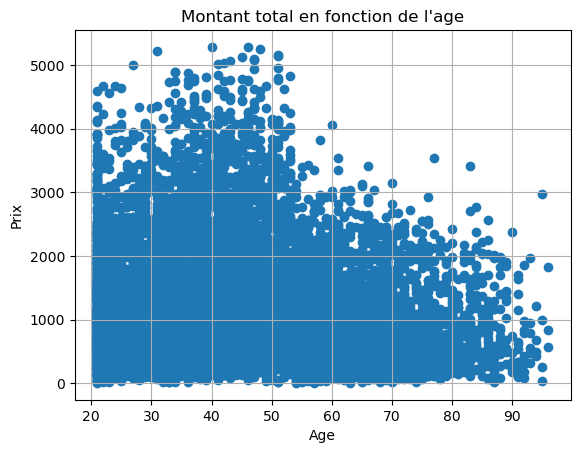

In [33]:
plt.scatter(montant_total['age'], montant_total['price'])
plt.title("Montant total en fonction de l'age")
plt.xlabel("Age")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

In [34]:
freq_achat = total.groupby('client_id')['session_id'].nunique().reset_index(name='freq_achat')
total = pd.merge(total,freq_achat,on='client_id',how='left')
total

,id_prod,date,session_id,client_id,price,categ,sex,birth,age,freq_achat
0,0_1259,2021/03,s_1,c_329,11.99,0,f,1967,58,35
1,0_1390,2021/03,s_2,c_664,19.37,0,m,1960,65,104
2,0_1352,2021/03,s_3,c_580,4.50,0,m,1988,37,134
3,0_1458,2021/03,s_4,c_7912,6.55,0,f,1989,36,100
4,0_1358,2021/03,s_5,c_2033,16.49,0,f,1956,69,70
...,...,...,...,...,...,...,...,...,...,...
640729,1_508,2023/02,s_348444,c_3573,21.92,1,f,1996,29,42
640730,2_37,2023/02,s_348445,c_50,48.99,2,f,1994,31,62
640731,1_695,2023/02,s_348446,c_488,26.99,1,f,1985,40,40
640732,0_1547,2023/02,s_348447,c_4848,8.99,0,m,1953,72,118


In [35]:
client_age = total[['client_id', 'age']].drop_duplicates()
freq_achat = pd.merge(freq_achat,client_age,on='client_id',how='left')
freq_achat

,client_id,freq_achat,age
0,c_1,34,70
1,c_10,34,69
2,c_100,5,33
3,c_1000,94,59
4,c_1001,47,43
...,...,...,...
8591,c_995,9,70
8592,c_996,80,55
8593,c_997,24,31
8594,c_998,24,24


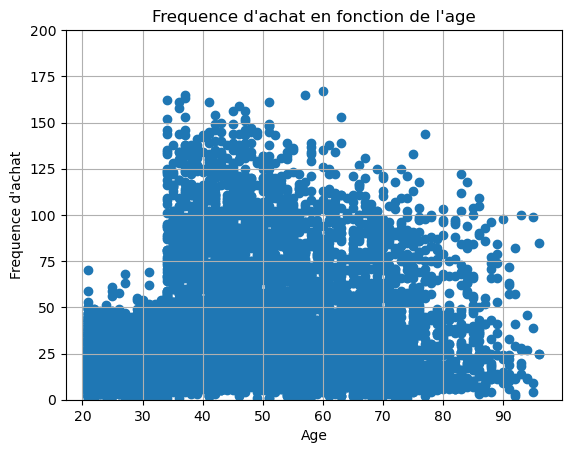

In [36]:
plt.scatter(freq_achat['age'],freq_achat['freq_achat'])
plt.title("Frequence d'achat en fonction de l'age")
plt.xlabel("Age")
plt.ylabel("Frequence d'achat")
plt.ylim(0,200)
plt.grid(True)
plt.show()

In [40]:
import dcor

# Convertir les deux colonnes en float
x = freq_achat['age'].astype(float)
y = freq_achat['freq_achat'].astype(float)

# Calcul de la distance correlation
dcorr = dcor.distance_correlation(x, y)
print(f"Distance correlation = {dcorr:.3f}")

# Test d'indépendance par permutation
test = dcor.independence.distance_covariance_test(
    x,
    y,
    num_resamples=100
)

print(f"p-value = {test.pvalue:.6f}")

Distance correlation = 0.238
p-value = 0.009901


In [41]:
panier_moyen = total.groupby(['client_id','session_id'])['price'].sum().reset_index()
panier_moyen = panier_moyen.groupby('client_id')['price'].mean().reset_index()
panier_moyen
total = pd.merge(total,panier_moyen,on='client_id',how='left')
total = total.rename(columns={'price_x':'price','price_y':'panier_moyen'})
total

,id_prod,date,session_id,client_id,price,categ,sex,birth,age,freq_achat,panier_moyen
0,0_1259,2021/03,s_1,c_329,11.99,0,f,1967,58,35,32.369714
1,0_1390,2021/03,s_2,c_664,19.37,0,m,1960,65,104,22.257115
2,0_1352,2021/03,s_3,c_580,4.50,0,m,1988,37,134,32.326045
3,0_1458,2021/03,s_4,c_7912,6.55,0,f,1989,36,100,30.222600
4,0_1358,2021/03,s_5,c_2033,16.49,0,f,1956,69,70,18.358000
...,...,...,...,...,...,...,...,...,...,...,...
640729,1_508,2023/02,s_348444,c_3573,21.92,1,f,1996,29,42,58.609524
640730,2_37,2023/02,s_348445,c_50,48.99,2,f,1994,31,62,70.203065
640731,1_695,2023/02,s_348446,c_488,26.99,1,f,1985,40,40,26.931500
640732,0_1547,2023/02,s_348447,c_4848,8.99,0,m,1953,72,118,20.935508


In [42]:
panier_moyen = pd.merge(panier_moyen,client_age,on='client_id',how='left')
panier_moyen

,client_id,price,age
0,c_1,18.500588,70
1,c_10,39.811765,69
2,c_100,50.970000,33
3,c_1000,24.381702,59
4,c_1001,38.805319,43
...,...,...,...
8591,c_995,21.045556,70
8592,c_996,20.466750,55
8593,c_997,62.083750,31
8594,c_998,117.592500,24


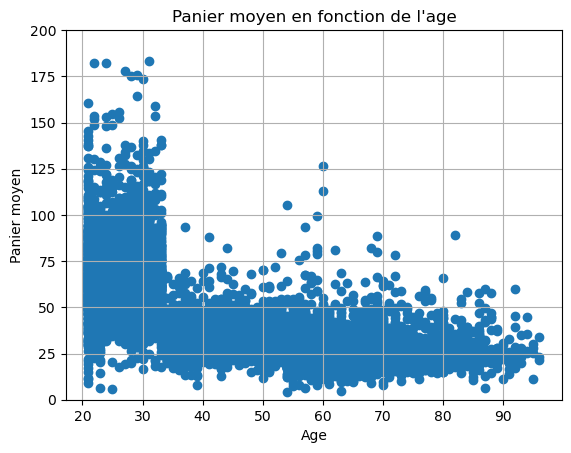

In [43]:
plt.scatter(panier_moyen['age'],panier_moyen['price'])
plt.title("Panier moyen en fonction de l'age")
plt.xlabel("Age")
plt.ylabel("Panier moyen")
plt.ylim(0,200)
plt.grid(True)
plt.show()

In [44]:
print(total['age'].corr(total['panier_moyen'],method='spearman'))

-0.5754307017190236


In [45]:
stats.spearmanr(total['age'],total['panier_moyen'])

SignificanceResult(statistic=-0.5754307017190236, pvalue=0.0)

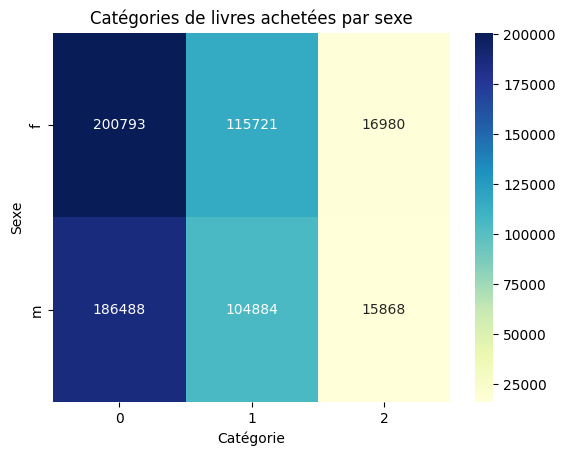

In [ ]:
crosstab = pd.crosstab(total['sex'], total['categ'])
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Catégories de livres achetées par sexe")
plt.xlabel("Catégorie")
plt.ylabel("Sexe")
plt.show()

In [ ]:
tab_contingence = pd.crosstab(total['sex'],total['categ'])
chi2, p, dof, expected = chi2_contingency(tab_contingence)
print("Tableau de contingence :")
print(tab_contingence)
print("\nStatistique du test khi2 :", chi2)
print("p-value :", p)
print("Degrés de liberté :", dof)
print("Fréquences attendues :\n", pd.DataFrame(expected, index=tab_contingence.index, columns=tab_contingence.columns))


Tableau de contingence :
categ       0       1      2
sex                         
f      200793  115721  16980
m      186488  104884  15868

Statistique du test khi2 : 22.66856665178056
p-value : 1.1955928116587024e-05
Degrés de liberté : 2
Fréquences attendues :
 categ              0              1             2
sex                                              
f      201574.896625  114822.131914  17096.971461
m      185706.103375  105782.868086  15751.028539


In [ ]:
alpha = 0.05
if p < alpha:
    print("\n=> Il y a une association significative entre le genre et la catégorie de livre acheté.")
else:
    print("\n=> Aucune association significative détectée entre le genre et la catégorie de livre acheté.")


=> Il y a une association significative entre le genre et la catégorie de livre acheté.


In [ ]:
groupes = [total[total['categ'] == cat]['age'] for cat in total['categ'].unique()]
f_stat, p_val = stats.f_oneway(*groupes)
print(f"Statistique F : {f_stat}")
print(f"Valeur p : {p_val}")
alpha = 0.05
if p_val < alpha:
    print("Il y a une différence significative entre les groupes.")
else:
    print("Il n'y a pas de différence significative entre les groupes.")

Statistique F : 39705.51969324279
Valeur p : 0.0
Il y a une différence significative entre les groupes.


In [ ]:
groupes

[0         58
 1         65
 2         37
 3         36
 4         69
           ..
 640723    39
 640724    41
 640727    48
 640732    72
 640733    44
 Name: age, Length: 387281, dtype: int64,
 7         57
 8         42
 9         55
 12        43
 15        36
           ..
 640725    41
 640726    45
 640728    53
 640729    29
 640731    40
 Name: age, Length: 220605, dtype: int64,
 42        21
 59        21
 94        21
 106       24
 123       21
           ..
 640637    21
 640653    26
 640689    79
 640717    27
 640730    31
 Name: age, Length: 32848, dtype: int64]

Text(0.5, 1.0, 'Catégorie de livres achetés et âge')

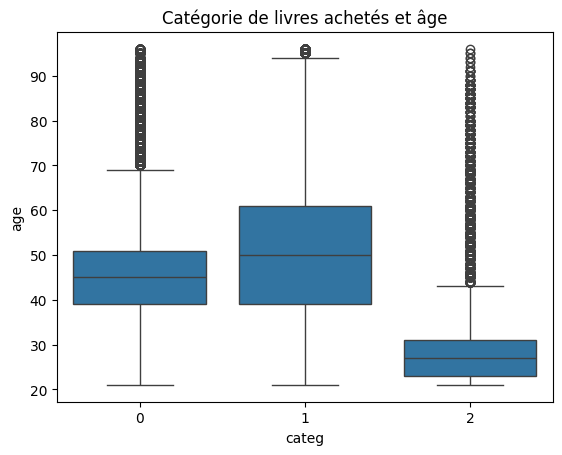

In [ ]:
sns.boxplot(data=total, x='categ', y='age')
plt.title('Catégorie de livres achetés et âge')